# Preliminary notebook to load data

Loading:
- neural data
- behavioral data
- timing data


This is the first notebook, so lots of just checking out what variables are, and then putting them into functions in load_data.py under utils

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 

In [2]:
delay = 150

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [4]:
model_name = model_dirs[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])

In [5]:
data_files

['/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815/neuraldata_raw_delay150.mat',
 '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815/bhvdata_raw_delay150.mat',
 '/home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815/timingdata_raw_delay150.mat']

## Let's do neural data first

### some scratch work

In [6]:
neuraldata_path = ld.find_files_keywords(model_dir, ['neuraldata',f'delay{delay}'])[0]


In [7]:
import h5py

# load hdf5 file
f = h5py.File(neuraldata_path, 'r')
list(f.keys())

['#refs#', 'all_lfp', 'all_rates', 'all_spk_times']

In [8]:
f['all_lfp'].shape

(2055, 200, 1000)

In [9]:
f['all_rates'].shape

(2055, 200, 1000)

In [24]:
f['all_spk_times']['/all_spk_times']

<HDF5 group "/all_spk_times" (1 members)>

In [27]:
f['all_spk_times'].keys()

<KeysViewHDF5 ['spk_times']>

In [ ]:
f['all_spk_times']['spk_times']

<HDF5 dataset "spk_times": shape (1000, 1), type "|O">

In [31]:
dataset = f['all_spk_times']['spk_times']

In [35]:
dataset

<HDF5 dataset "spk_times": shape (1000, 1), type "|O">

In [36]:
cell_refs = f['all_spk_times']['spk_times']
refs = cell_refs[:]
spk_times_list = [f[refs[i][0]][:] for i in range(refs.shape[0])]

In [43]:
refs = f['all_spk_times']['spk_times']

spk_times_list = []
for i in range(refs.shape[0]):
    inner_refs = f[refs[i][0]][:]  # This gets you the array of inner object refs
    spike_times = [f[ref][:] for ref in inner_refs.flat]  # Flatten in case it's (1, N) shape
    spk_times_list.append(spike_times)

In [45]:
len(spk_times_list)

1000

In [48]:
len(spk_times_list[0])

200

### cleaned up

In [29]:
importlib.reload(ld)

lfp_data, spk_times_df, rates_data = ld.load_neural_data(model_name, condn_phrase=f'delay{delay}',
                                                  load_LFP=True, load_spikes=True, load_rates=True)


In [7]:
spk_times_df.head()

,cell_id,trial_id,cell_type,spk_times,model_name
0,0,0,exc,"[0.0, 3710.0, 4404.0, 15955.0, 17421.0, 19622....",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...
1,1,0,exc,"[0.0, 6821.0]",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...
2,2,0,inh,"[1304.0, 3437.0, 5146.0, 6980.0, 7811.0, 9111....",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...
3,3,0,exc,"[1, 0]",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...
4,4,0,exc,[0.0],Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...


#### plot spikes

In [7]:
# get the trial timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase=f'delay{delay}')

In [8]:
# get the behavioral data too
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=f'delay{delay}')

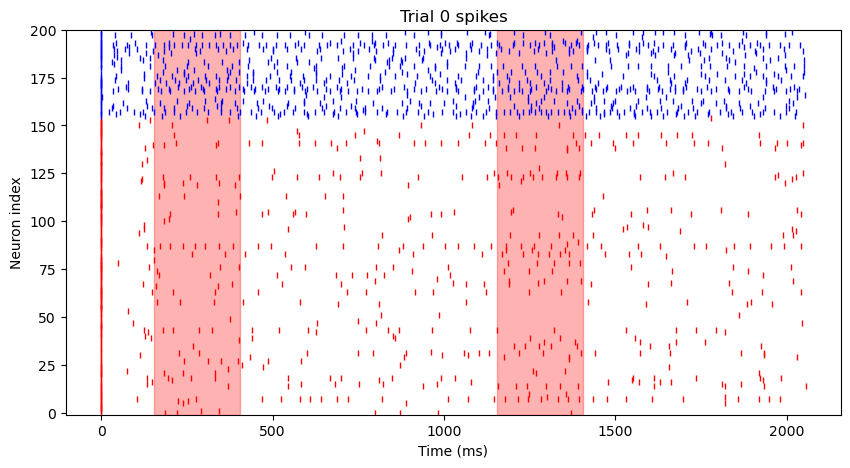

In [10]:
# plot all neurons in one trial

trial_id = 0
trial_df = spk_times_df[spk_times_df['trial_id'] == trial_id]

plt.figure(figsize=(10, 5))

# sort trial_df by exc and inh
trial_df = trial_df.sort_values(by='cell_type')

for n_cell in range(len(trial_df)):
    cell_spk_times = trial_df.iloc[n_cell]['spk_times']/fs_dict['spk']*1000
    if trial_df.iloc[n_cell]['cell_type'] == 'exc':
        plt.plot(cell_spk_times, np.ones_like(cell_spk_times) * n_cell, '|', markersize=5, color='red')
    else:
        plt.plot(cell_spk_times, np.ones_like(cell_spk_times) * n_cell, '|', markersize=5, color='blue')
plt.title(f"Trial {trial_id} spikes")
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.ylim(-1, len(trial_df))

# shade stim1 and stim2 periods
stim1_start = times_real['stim1_on'] * 1000
stim1_end = times_real['stim1_off'] *1000
stim2_start = times_real['stim2_on'] * 1000
stim2_end = times_real['stim2_off'] * 1000
trial_label = trial_labels[trial_id]
stim1_color = 'blue' if trial_label[0] == 1 else 'red'
stim2_color = 'blue' if trial_label[1] == 1 else 'red'
plt.axvspan(stim1_start, stim1_end, color=stim1_color, alpha=0.3, label='Stim 1')
plt.axvspan(stim2_start, stim2_end, color=stim2_color, alpha=0.3, label='Stim 2')

plt.show()


In [13]:
unique_labels, indices = np.unique(trial_labels, axis=0, return_index=True)

In [14]:
print(unique_labels)
print(indices)

[[-1 -1]
 [-1  1]
 [ 1 -1]
 [ 1  1]]
[  0 250 500 750]


In [16]:
unique_labels.shape

(4, 2)

In [19]:
unique_labels, indices = np.unique(trial_labels, axis=0, return_index=True)
indices = np.concatenate((indices, [len(cell_df)]))
for i in range(len(unique_labels)):
    stim1_color = 'blue' if unique_labels[i,0] == 1 else 'red'
    print(unique_labels[i,0], stim1_color)
    stim2_color = 'blue' if unique_labels[i,1] == 1 else 'red'
    print(unique_labels[i,1], stim2_color)
    print(indices[i], indices[i+1])
    # plt.axvspan(stim1_start, stim1_end, ymin=indices[i], ymax=indices[i+1], color=stim1_color, alpha=0.3)
    # plt.axvspan(stim2_start, stim2_end, ymin=indices[i], ymax=indices[i+1], color=stim2_color, alpha=0.3)

-1 red
-1 red
0 250
-1 red
1 blue
250 500
1 blue
-1 red
500 750
1 blue
1 blue
750 1000


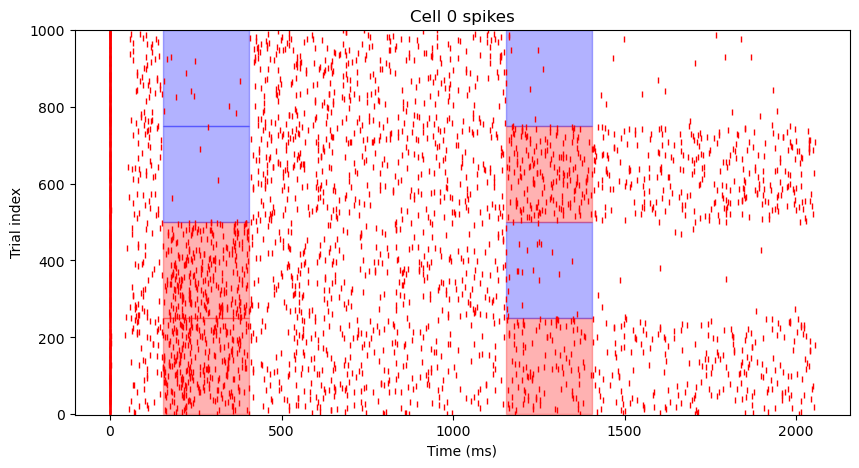

In [24]:
# plot all trials in one neuron

import matplotlib.patches as patches

cell_id = 0
cell_df = spk_times_df[spk_times_df['cell_id'] == cell_id]

fig, ax = plt.subplots(figsize=(10, 5))
for n_trial in range(len(cell_df)):
    cell_spk_times = cell_df.iloc[n_trial]['spk_times']/fs_dict['spk']*1000
    if cell_df.iloc[n_trial]['cell_type'] == 'exc':
        plt.plot(cell_spk_times, np.ones_like(cell_spk_times) * n_trial, '|', markersize=5, color='red')
    else:
        plt.plot(cell_spk_times, np.ones_like(cell_spk_times) * n_trial, '|', markersize=5, color='blue')
plt.title(f"Cell {cell_id} spikes")
plt.xlabel('Time (ms)')
plt.ylabel('Trial index')
plt.ylim(-1, len(cell_df))
# shade stim1 and stim2 periods
stim1_start = times_real['stim1_on'] * 1000
stim1_end = times_real['stim1_off'] *1000
stim2_start = times_real['stim2_on'] * 1000
stim2_end = times_real['stim2_off'] * 1000

# shade trials by stim identity
trial_labels = trial_labels[cell_df['trial_id'].values]

unique_labels, indices = np.unique(trial_labels, axis=0, return_index=True)
indices = np.concatenate((indices, [len(cell_df)]))
for i in range(len(unique_labels)):
    stim1_color = 'b' if unique_labels[i,0] == 1 else 'r'
    stim2_color = 'b' if unique_labels[i,1] == 1 else 'r'

    height = indices[i+1] - indices[i]
    rect1 = patches.Rectangle((stim1_start, indices[i]), 
                            stim1_end - stim1_start, height,
                            color=stim1_color, alpha=0.3)
    rect2 = patches.Rectangle((stim2_start, indices[i]), 
                            stim2_end - stim2_start, height,
                            color=stim2_color, alpha=0.3)
    ax.add_patch(rect1)
    ax.add_patch(rect2)

    # plt.axvspan(stim1_start, stim1_end, ymin=indices[i], ymax=indices[i+1], color=stim1_color, alpha=0.3)
    # plt.axvspan(stim2_start, stim2_end, ymin=indices[i], ymax=indices[i+1], color=stim2_color, alpha=0.3)

# plt.legend()
plt.show()

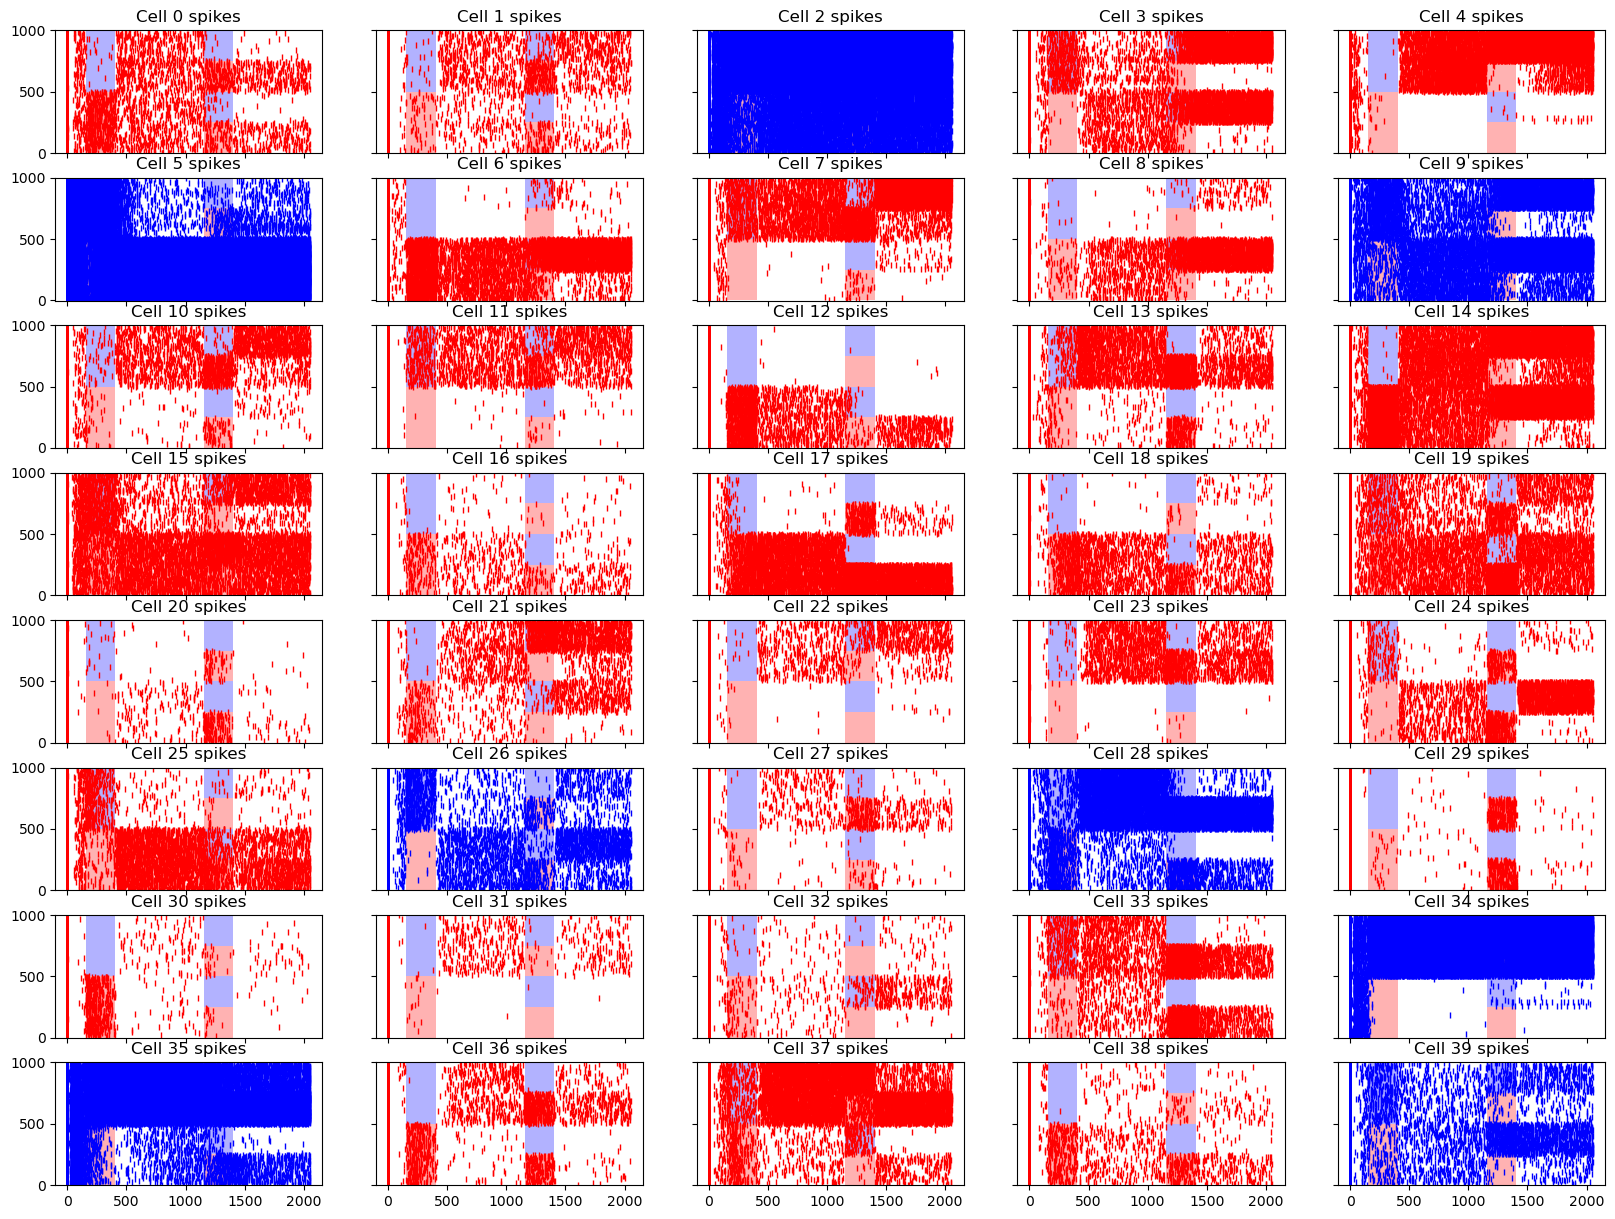

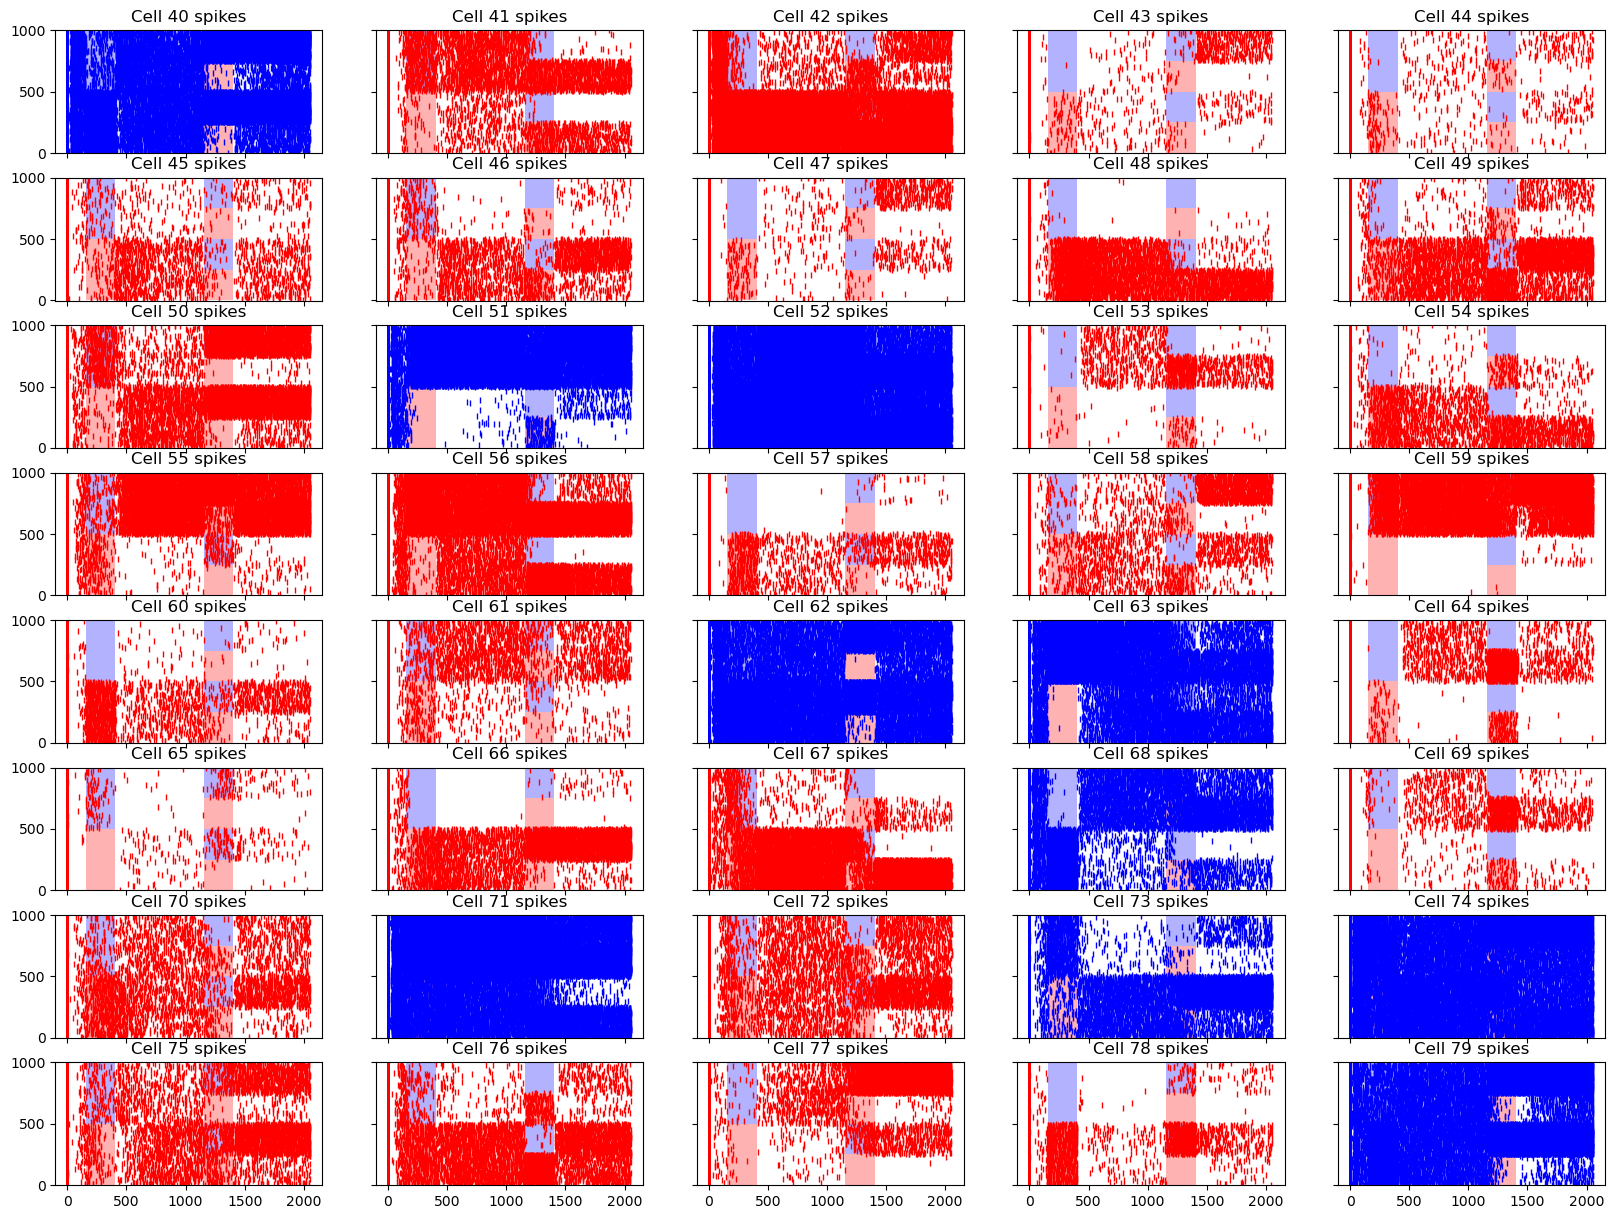

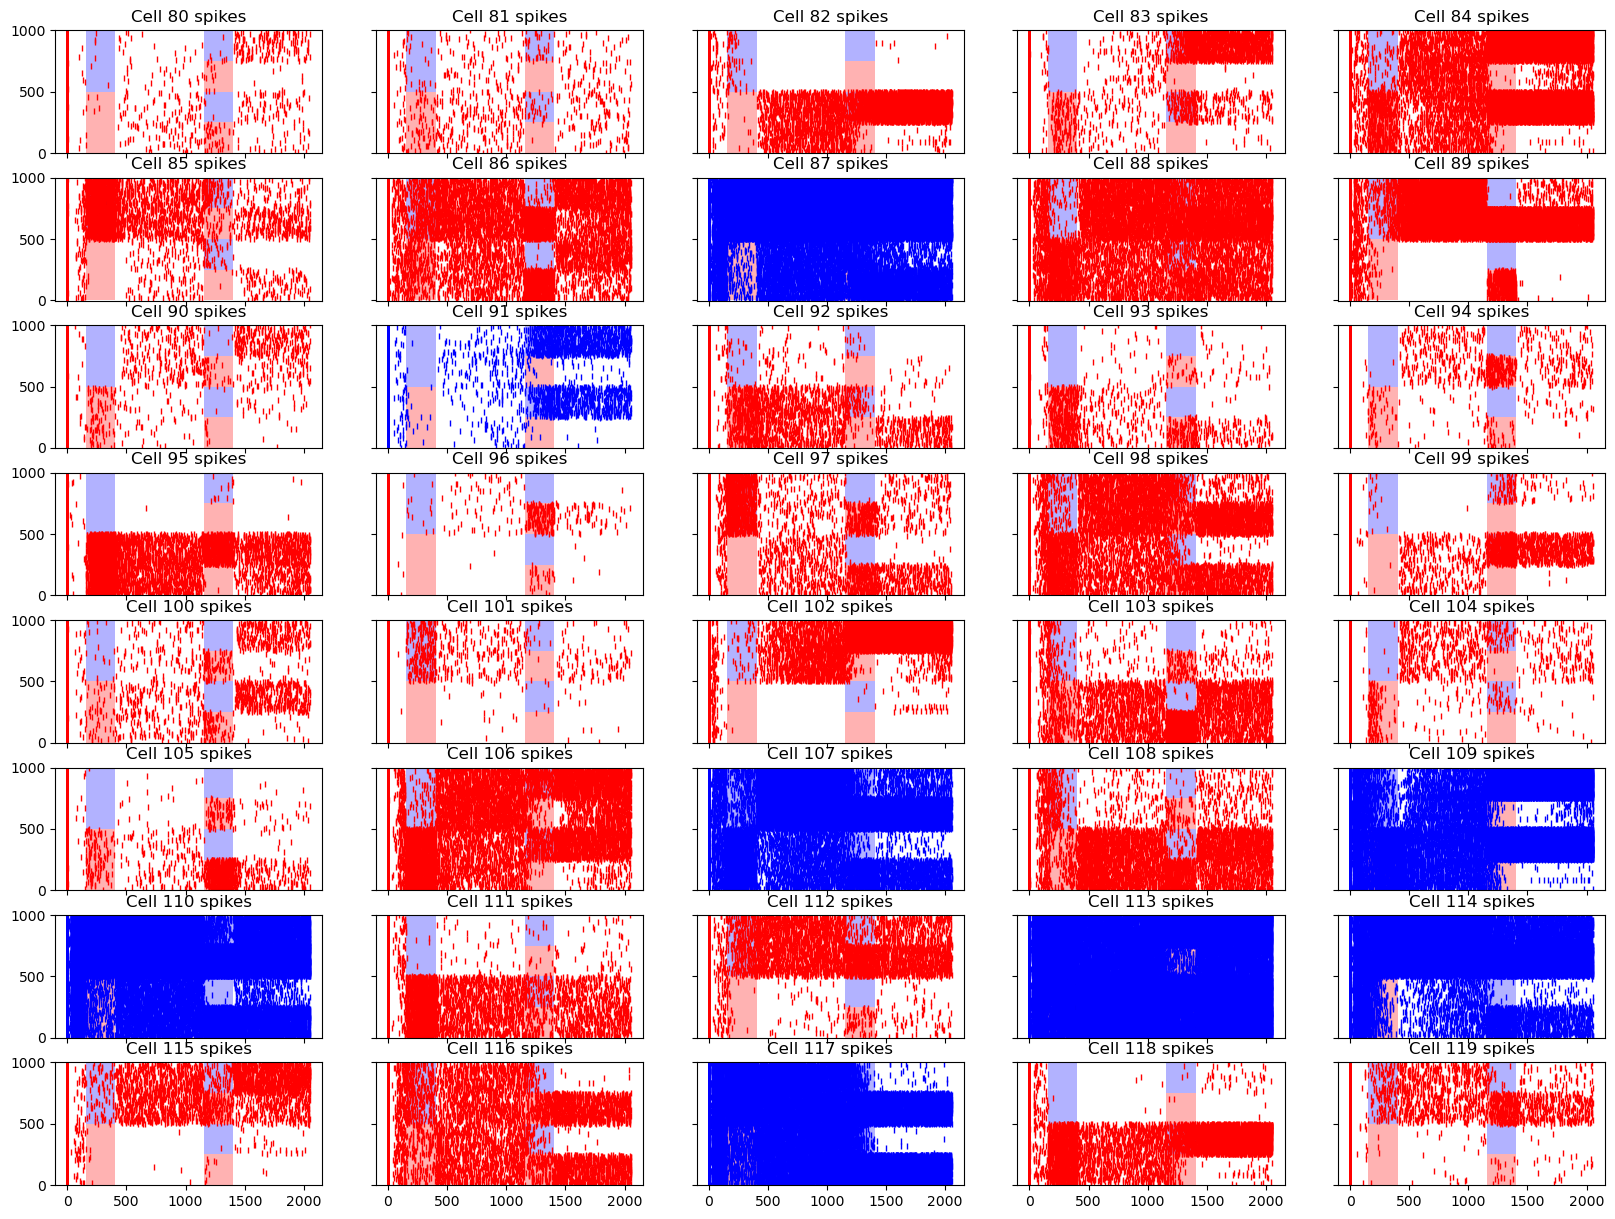

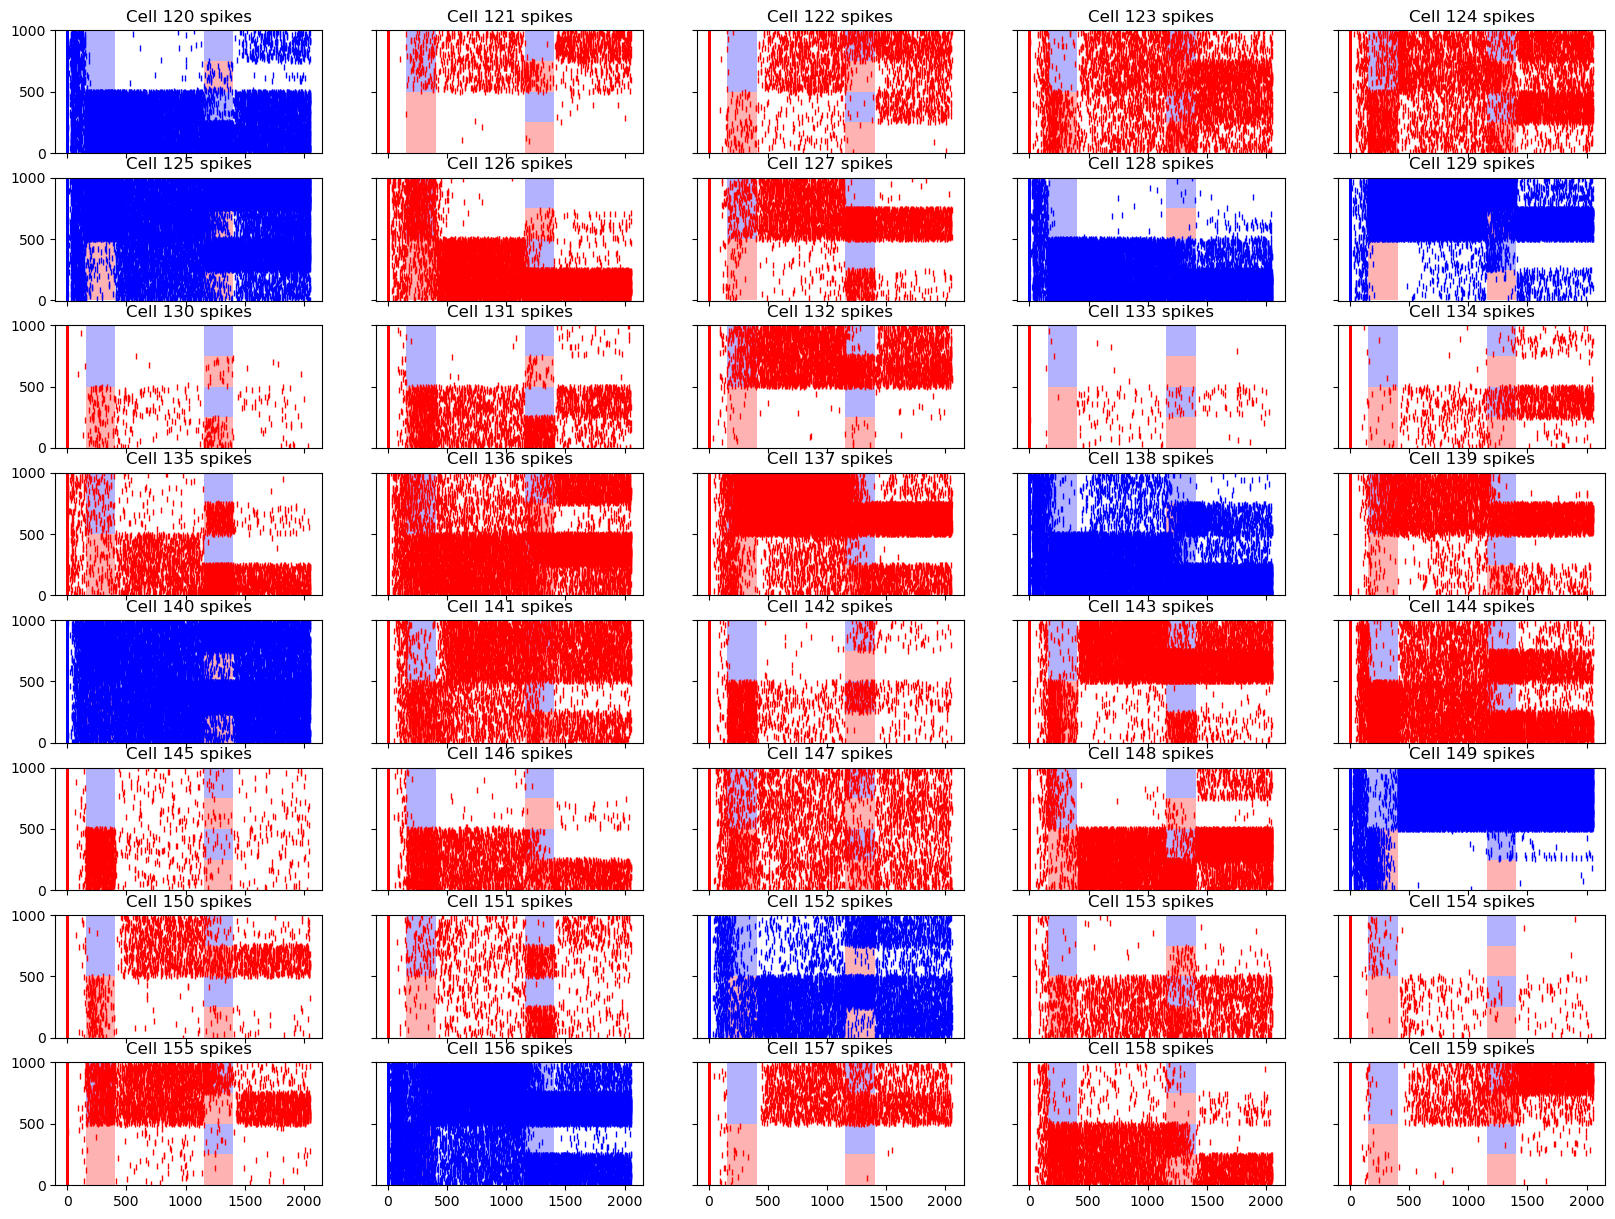

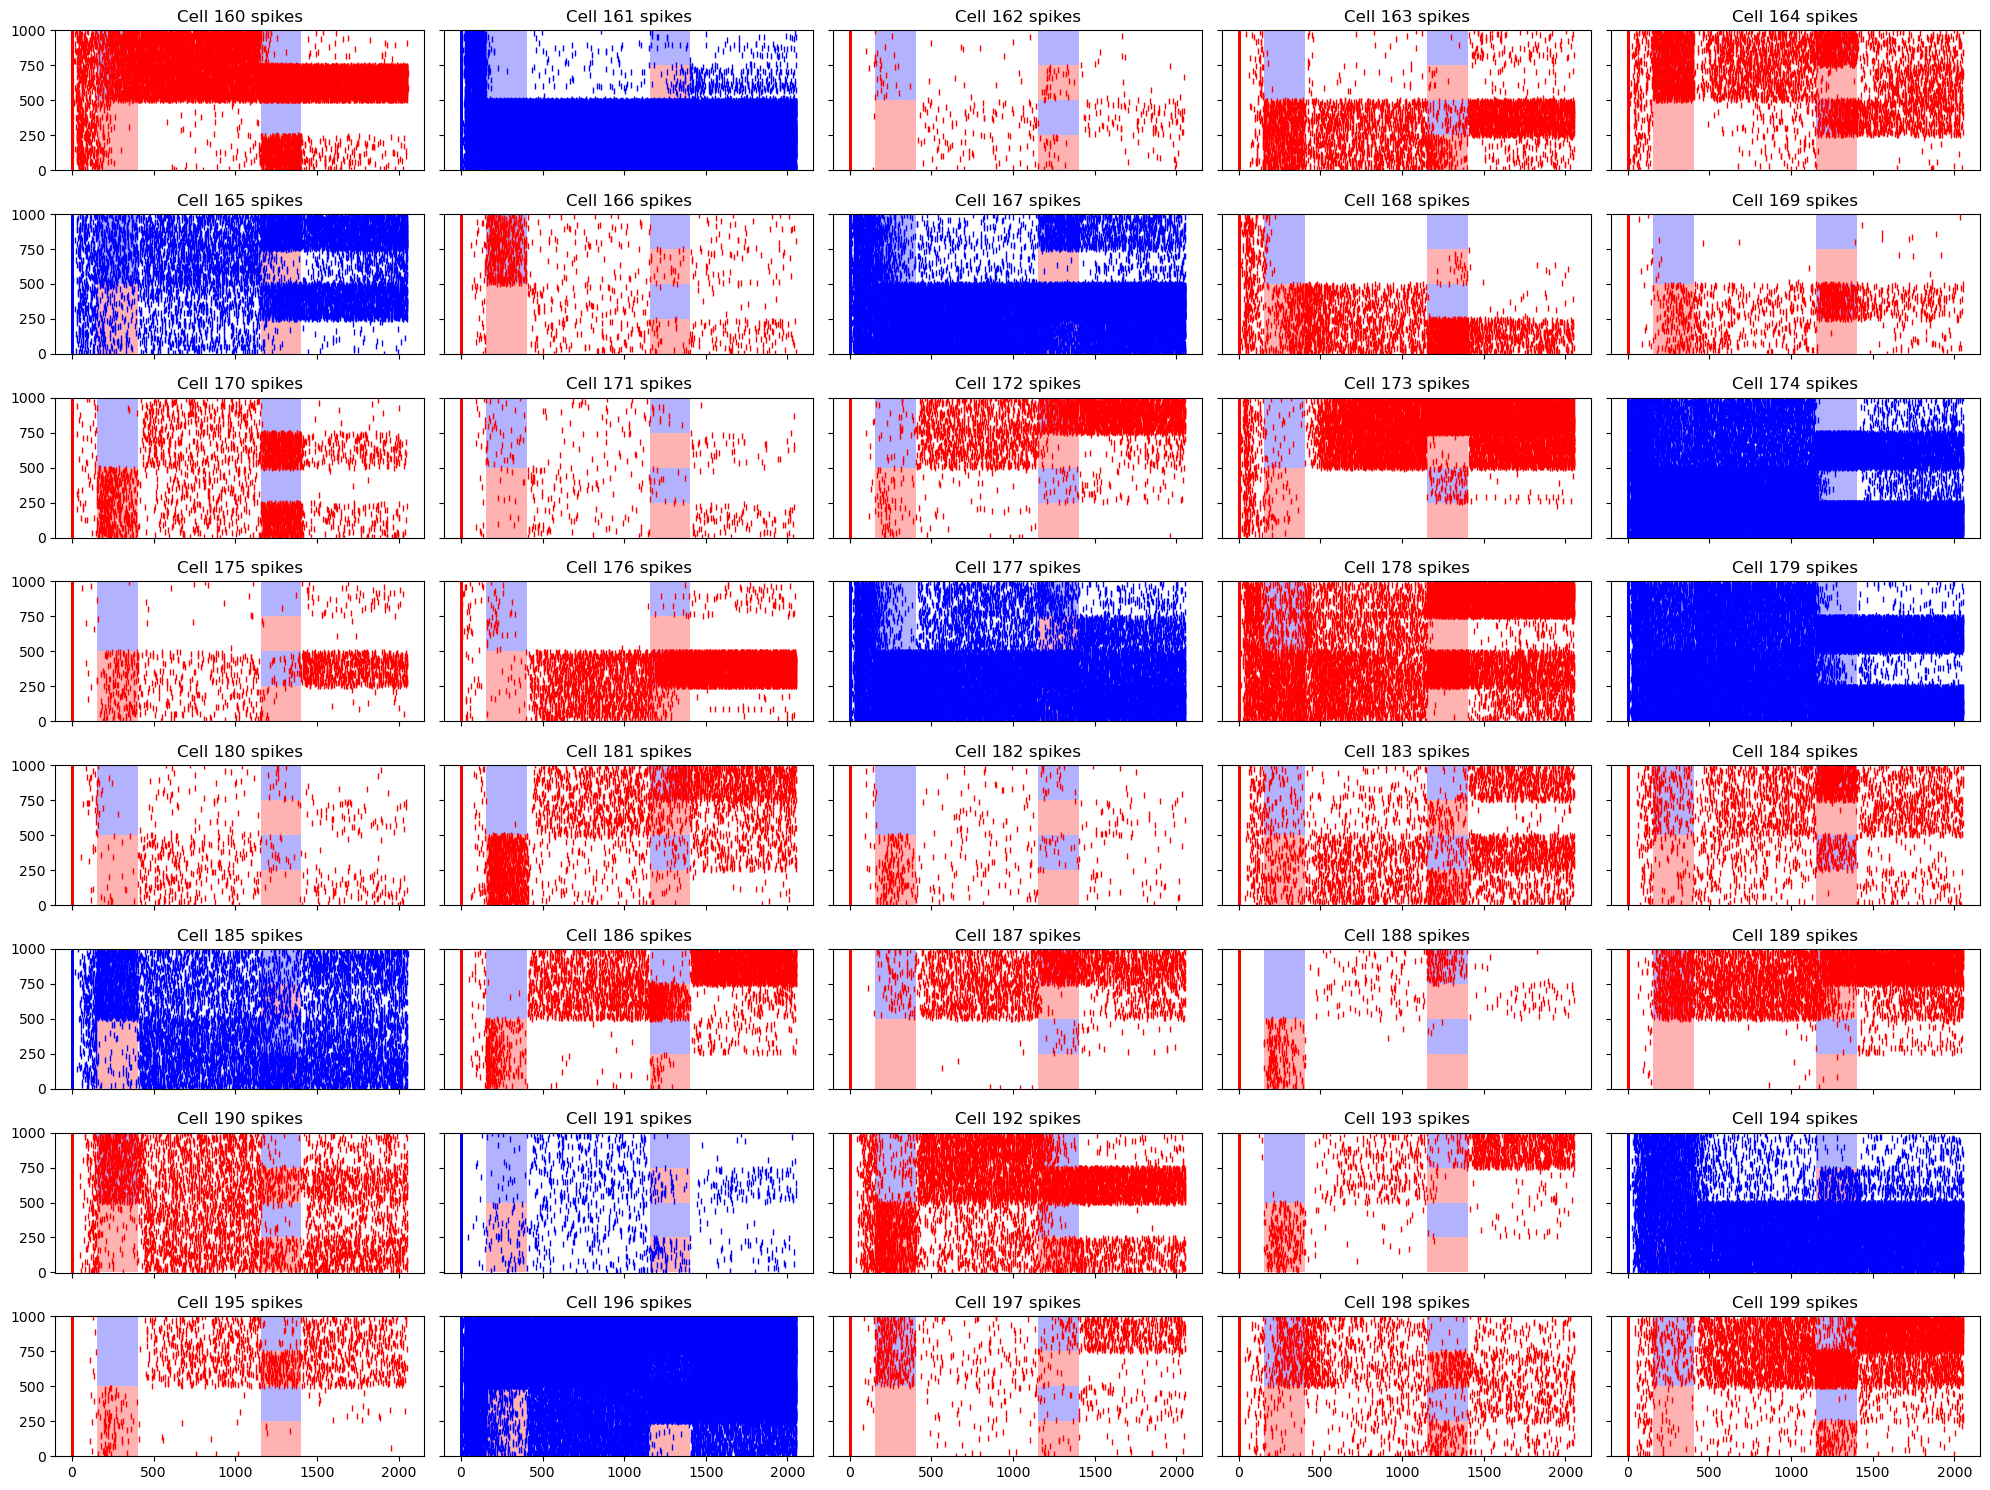

In [9]:
# plot all neurons selectivity in subplots

import matplotlib.patches as patches

n_cells = len(spk_times_df['cell_id'].unique())

for n_cell in range(n_cells):
    # plot 25 neurons per figure
    if n_cell % 40 == 0:
        fig, axs = plt.subplots(8, 5, figsize=(20, 15), sharex=True, sharey=True)
        axs = axs.flatten()

    # Get current cell data
    cell_id = n_cell
    cell_df = spk_times_df[spk_times_df['cell_id'] == cell_id].reset_index(drop=True)

    # Choose axis for this cell
    ax = axs[n_cell % 40]
    ax.set_title(f"Cell {cell_id} spikes")
    # ax.set_xlabel('Time (ms)')
    # ax.set_ylabel('Trial index')
    ax.set_ylim(-1, len(cell_df))

    # Plot spikes for each trial
    for n_trial in range(len(cell_df)):
        spk_times = cell_df.loc[n_trial, 'spk_times'] / fs_dict['spk'] * 1000  # Convert to ms
        trial_y = np.ones_like(spk_times) * n_trial
        color = 'red' if cell_df.loc[n_trial, 'cell_type'] == 'exc' else 'blue'
        ax.plot(spk_times, trial_y, '|', markersize=5, color=color)

    # Shade stim1 and stim2
    stim1_start = times_real['stim1_on'] * 1000
    stim1_end = times_real['stim1_off'] * 1000
    stim2_start = times_real['stim2_on'] * 1000
    stim2_end = times_real['stim2_off'] * 1000

    # Shade trials based on stim identity
    trial_ids = cell_df['trial_id'].values
    stim_labels = trial_labels[trial_ids]  # shape: (n_trials, 2)
    unique_labels, indices = np.unique(stim_labels, axis=0, return_index=True)
    indices = np.concatenate((np.sort(indices), [len(cell_df)]))  # Ensure sorted trial blocks

    for i in range(len(unique_labels)):
        stim1_color = 'b' if unique_labels[i, 0] == 1 else 'r'
        stim2_color = 'b' if unique_labels[i, 1] == 1 else 'r'
        y_start = indices[i]
        height = indices[i+1] - y_start

        rect1 = patches.Rectangle((stim1_start, y_start), stim1_end - stim1_start, height,
                                  facecolor=stim1_color, edgecolor='none', alpha=0.3)
        rect2 = patches.Rectangle((stim2_start, y_start), stim2_end - stim2_start, height,
                                  facecolor=stim2_color, edgecolor='none', alpha=0.3)
        ax.add_patch(rect1)
        ax.add_patch(rect2)

# Optionally call plt.tight_layout() or plt.show() outside the loop
plt.tight_layout()
plt.show()

#### plot LFP

In [ ]:
lfp_data.shape

(2055, 200, 1000)

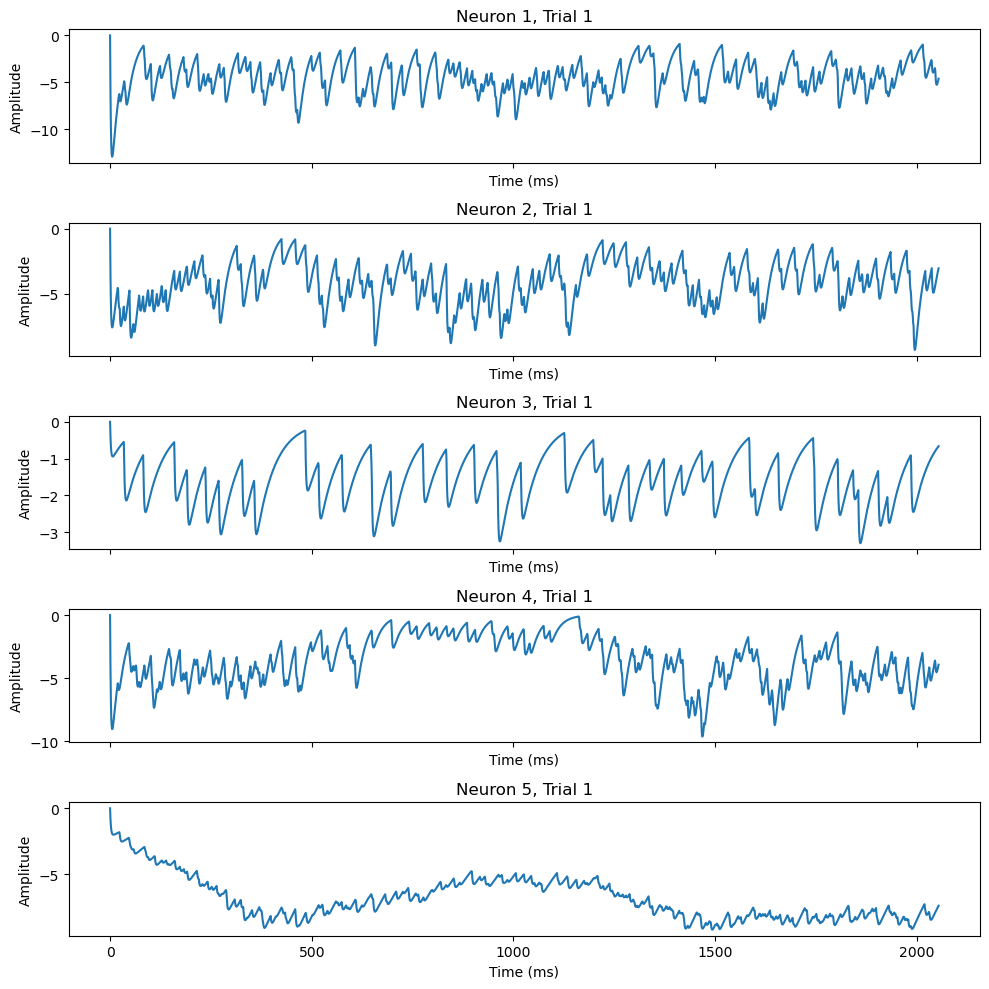

In [ ]:
# plot some LFP data for some neurons

fig, axs = plt.subplots(5,1, figsize=(10, 10), sharex=True)
for i in range(5):
    axs[i].plot(np.arange(0, 2055, 1), lfp_data[:,i,0]) 
    axs[i].set_title(f'Neuron {i+1}, Trial 1')
    axs[i].set_ylabel('Amplitude')
    axs[i].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()

#### plot rates

In [13]:
rates_data.shape

(2055, 200, 1000)

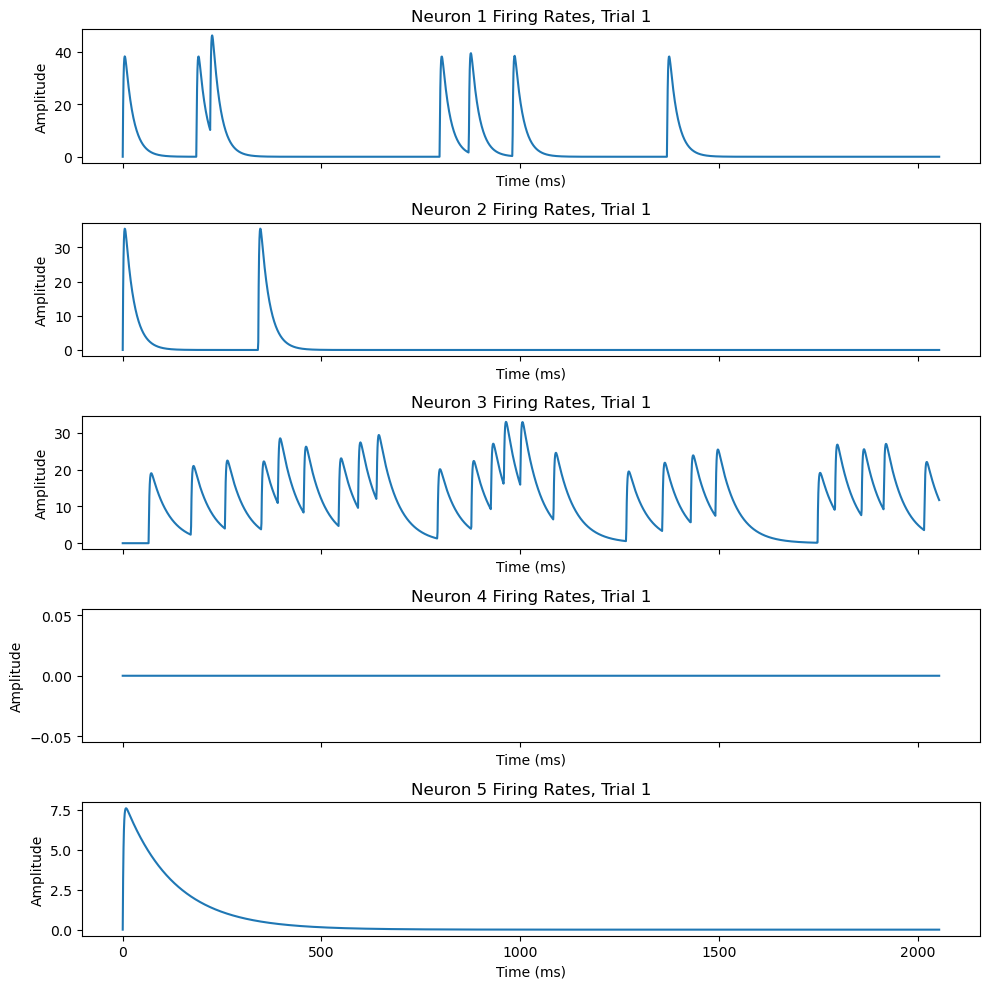

In [ ]:
# plot some LFP data for some neurons

fig, axs = plt.subplots(5,1, figsize=(10, 10), sharex=True)
for i in range(5):
    axs[i].plot(np.arange(0, 2055, 1), rates_data[:,i,0]) 
    axs[i].set_title(f'Neuron {i+1} Firing Rates, Trial 1')
    axs[i].set_ylabel('Amplitude')
    axs[i].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()

#### something abt the weight matrices

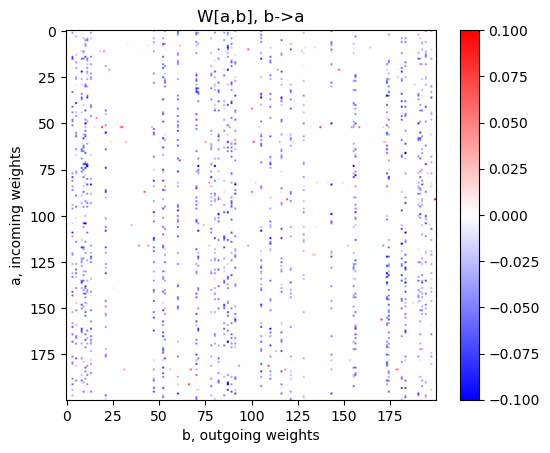

In [10]:
importlib.reload(ld)
final_w = ld.get_weights(model_name)
plt.imshow(final_w, vmin=-0.1, vmax=0.1, cmap='bwr')
plt.xlabel('b, outgoing weights')
plt.ylabel('a, incoming weights')
plt.title('W[a,b], b->a')
plt.colorbar();

In [11]:
exc_ind, inh_ind = ld.get_celltype_label(model_name)

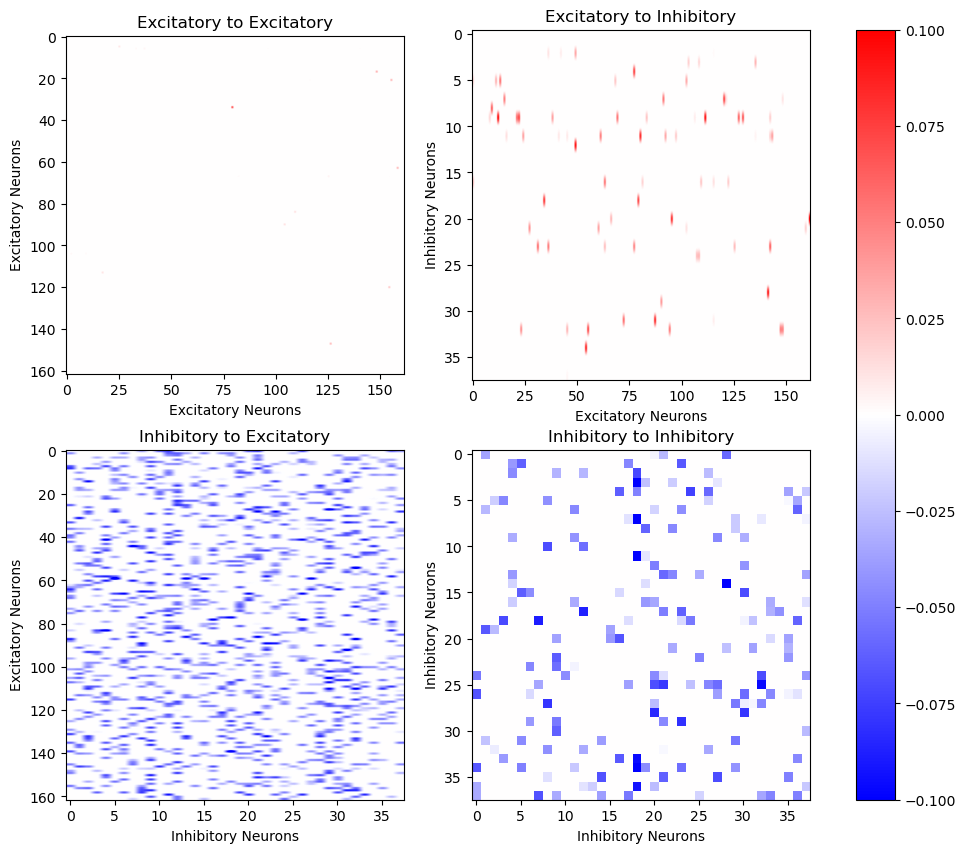

In [12]:
# create masks

ee_mask = np.ix_(exc_ind, exc_ind)
ie_mask = np.ix_(exc_ind, inh_ind)
ei_mask = np.ix_(inh_ind, exc_ind)
ii_mask = np.ix_(inh_ind, inh_ind)

# plot the weights
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs[0, 0].imshow(final_w[ee_mask], vmin=-0.1, vmax=0.1, cmap='bwr', aspect='auto')
axs[0, 0].set_title('Excitatory to Excitatory')
axs[0, 0].set_xlabel('Excitatory Neurons')
axs[0, 0].set_ylabel('Excitatory Neurons')
axs[0, 1].imshow(final_w[ei_mask], vmin=-0.1, vmax=0.1, cmap='bwr', aspect='auto')
axs[0, 1].set_title('Excitatory to Inhibitory')
axs[0, 1].set_xlabel('Excitatory Neurons')
axs[0, 1].set_ylabel('Inhibitory Neurons')
axs[1, 0].imshow(final_w[ie_mask], vmin=-0.1, vmax=0.1, cmap='bwr', aspect='auto')
axs[1, 0].set_title('Inhibitory to Excitatory')
axs[1, 0].set_xlabel('Inhibitory Neurons')
axs[1, 0].set_ylabel('Excitatory Neurons')
axs[1, 1].imshow(final_w[ii_mask], vmin=-0.1, vmax=0.1, cmap='bwr', aspect='auto')
axs[1, 1].set_title('Inhibitory to Inhibitory')
axs[1, 1].set_xlabel('Inhibitory Neurons')
axs[1, 1].set_ylabel('Inhibitory Neurons')
plt.colorbar(axs[0, 0].imshow(final_w[ee_mask], vmin=-0.1, vmax=0.1, cmap='bwr'), ax=axs, orientation='vertical')
# plt.tight_layout()
plt.show()

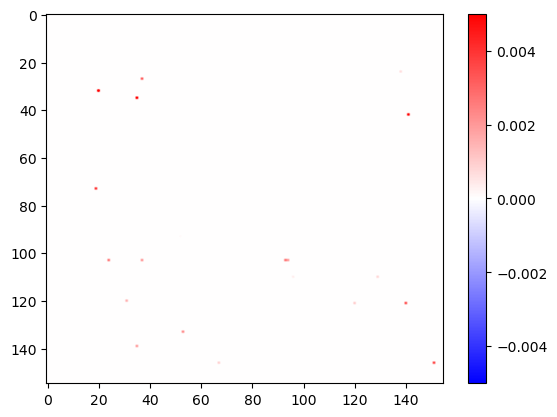

In [ ]:
plt.imshow(final_w[ee_mask], cmap='bwr', aspect='auto', vmin=-0.005, vmax=0.005)
plt.colorbar();

In [48]:
# Initialize list for flattened rows
flattened_rows = []

# Iterate through all neuron connections
n_neurons = final_w.shape[0]
for presyn_id in range(n_neurons):
    for postsyn_id in range(n_neurons):
        weight = final_w[postsyn_id, presyn_id]
        if weight != 0:
            # Determine the cell type of presynaptic and postsynaptic neurons
            presyn_type = 'exc' if presyn_id in exc_ind else 'inh'
            postsyn_type = 'exc' if postsyn_id in exc_ind else 'inh'
            
            flattened_rows.append({
                'presyn_id': presyn_id,
                'postsyn_id': postsyn_id,
                'weight': weight,
                'presyn_type': presyn_type,
                'postsyn_type': postsyn_type
            })

# Convert the list of dictionaries to a DataFrame
connectivity_df = pd.DataFrame(flattened_rows)

In [49]:
connectivity_df

,presyn_id,postsyn_id,weight,presyn_type,postsyn_type
0,2,10,-0.033834,inh,exc
1,2,11,-0.029063,inh,exc
2,2,42,-0.026357,inh,exc
3,2,54,-0.034750,inh,exc
4,2,61,-0.032047,inh,exc
...,...,...,...,...,...
1700,196,179,-0.041422,inh,inh
1701,196,188,-0.027652,inh,exc
1702,196,193,-0.040745,inh,exc
1703,198,74,0.004789,exc,inh


In [50]:
inh_ind

array([  2,   5,   9,  26,  28,  34,  35,  39,  40,  51,  52,  62,  63,
        68,  71,  73,  74,  79,  87,  91, 107, 109, 110, 113, 114, 117,
       120, 125, 128, 129, 138, 140, 149, 152, 156, 161, 165, 167, 174,
       177, 179, 185, 191, 194, 196])

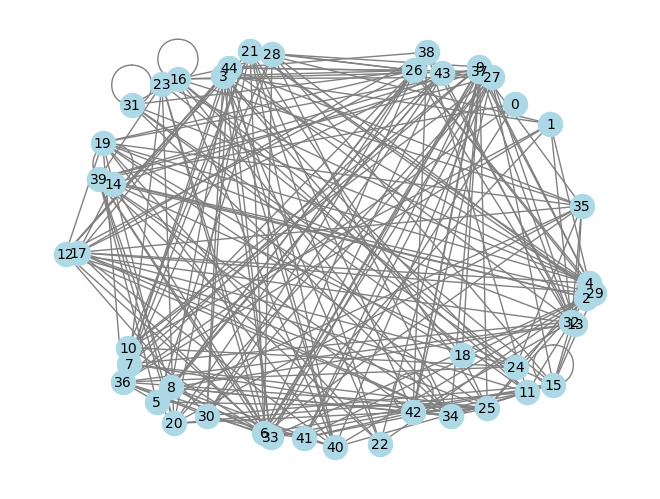

In [54]:
import networkx as nx 

G = nx.from_numpy_array(final_w[np.ix_(inh_ind, inh_ind)].T)
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', font_size=10)
plt.show()

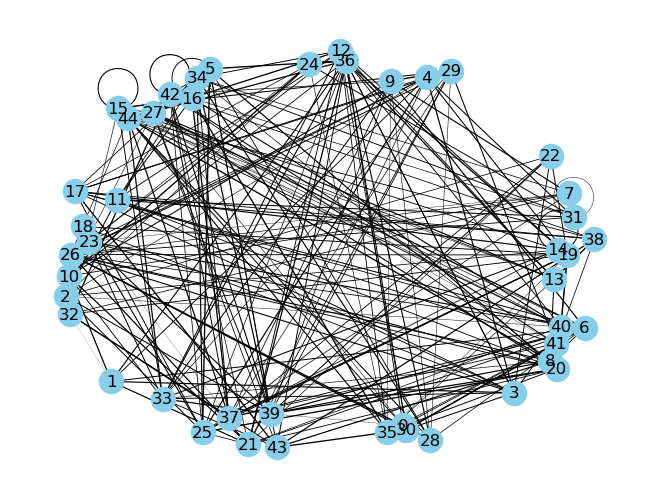

In [57]:
# Extract edge weights from the matrix (the matrix entries are the weights)
weights = [G[u][v]['weight'] for u, v in G.edges()]

# Normalize weights (optional) for better visualization of edge thickness
min_weight = min(weights)
max_weight = max(weights)
normalized_weights = [(w - min_weight) / (max_weight - min_weight) for w in weights]  # Scale to a range for edge thickness

# Draw the graph, using the normalized weights to scale edge widths
nx.draw(G, with_labels=True, node_color='skyblue', width=normalized_weights)
plt.show()

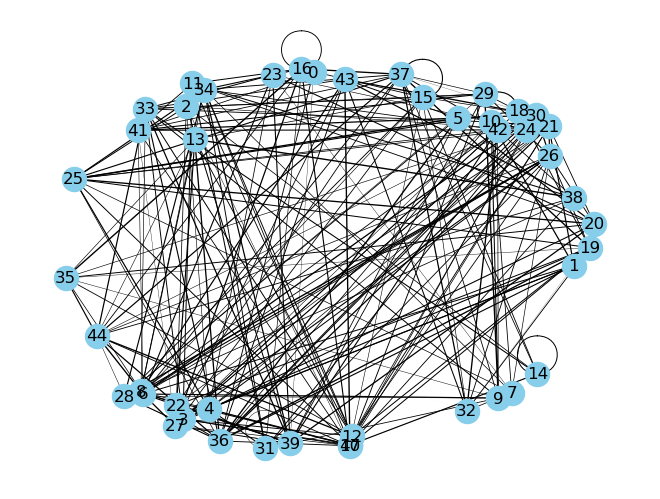

In [59]:
pos = nx.spring_layout(G)  # Force-directed layout (Spring layout)
nx.draw(G, pos, with_labels=True, node_color='skyblue', width=normalized_weights)
plt.show()

In [66]:
from sklearn.cluster import SpectralClustering

# Perform spectral clustering
n_clusters = 3  # Number of clusters
spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', assign_labels='discretize')
adjacency_matrix = final_w[np.ix_(inh_ind,inh_ind)].T
spectral_clustering.fit(adjacency_matrix)
labels = spectral_clustering.labels_
print(labels.shape)

/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:310: UserWarning: Array is not symmetric, and will be converted to symmetric by average with its transpose.
  adjacency = check_symmetric(adjacency)
/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/scipy/sparse/csgraph/_laplacian.py:554: RuntimeWarning: invalid value encountered in sqrt
  w = np.where(isolated_node_mask, 1, np.sqrt(w))


ValueError: Input contains NaN.

## Now load behavioral data

In [57]:
bhvdata_path = ld.find_files_keywords(model_dir, ['bhvdata',f'delay{delay}'])[0]
bhvdata_path

'/scratch/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659/bhvdata_raw_delay150.mat'

In [61]:
bhv_mat = scipy.io.loadmat(bhvdata_path)
trial_labels = bhv_mat['all_trial_labels']
trial_perfs = bhv_mat['all_trial_perfs']
print(trial_labels.shape)
print(trial_perfs.shape)
del bhv_mat

(1000, 2)
(1000, 1)


0.16497272501841023
0.063118935352238
0.0
0.0


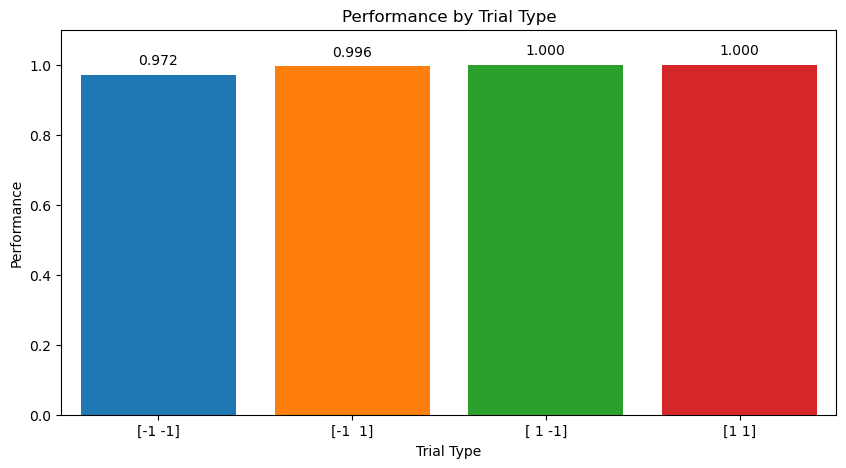

In [78]:
# plot performance for each trial type

unique_labels = np.unique(trial_labels, axis=0)

trial_performances = []
plt.figure(figsize=(10, 5))
for i in range(unique_labels.shape[0]):
    trial_type = unique_labels[i]
    trial_indices = np.where(np.all(trial_labels == trial_type, axis=1))[0]
    trial_performance = trial_perfs[trial_indices]
    trial_performances.append(trial_performance)
    print(trial_performance.std())
    # plt.bar(i, trial_performance.mean(), yerr=trial_performance.std(), capsize=5)
    plt.bar(i, trial_performance.mean())
    # print performance on top of bar
    plt.text(i, trial_performance.mean() + 0.02, f'{trial_performance.mean():.3f}', ha='center', va='bottom')


plt.xticks(range(len(unique_labels)), [str(label) for label in unique_labels])
plt.xlim(-0.5, len(unique_labels) - 0.5)
plt.ylim(0, 1.1)
# plt.axhline(y=0.5, color='r', linestyle='--')
# plt.axhline(y=0.75, color='g', linestyle='--')
plt.title('Performance by Trial Type')
plt.xlabel('Trial Type')
plt.ylabel('Performance')
# plt.grid()
plt.show()

## Now load timing data

In [58]:
timingdata_path = ld.find_files_keywords(model_dir, ['timingdata',f'delay{delay}'])[0]
timingdata_path

'/scratch/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659/timingdata_raw_delay150.mat'

In [62]:
timing_mat = scipy.io.loadmat(timingdata_path)
timing_mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'T', 'delay', 'fs_ds', 'fs_rate', 'fs_spk', 'stim_dur', 'stim_on'])

In [64]:
timing_mat['T'][0][0]

411

In [ ]:
times_rate = {
    'T': timing_mat['T'][0][0],
    'stim_on': timing_mat['stim_on'][0][0],
    'stim_dur': timing_mat['stim_dur'][0][0],
    'delay': timing_mat['delay'][0][0],
    'fs': timing_mat['fs_rate'][0][0],
}

fs_dict = {
    'rate': timing_mat['fs_rate'][0][0], # refers to rate network
    'spk': timing_mat['fs_spk'][0][0],
    'ds': timing_mat['fs_ds'][0][0], # applies to lfp and to firing rate
}

times_real = {
    'stim1_on': times_rate['stim_on']/times_rate['fs'],
    'stim1_off': (times_rate['stim_on'] + times_rate['stim_dur'])/times_rate['fs'],
    'stim2_on': (times_rate['stim_on'] + times_rate['stim_dur'] + times_rate['delay'])/times_rate['fs'],
    'stim2_off': (times_rate['stim_on'] + 2*times_rate['stim_dur'] + times_rate['delay'])/times_rate['fs'],
}